# Run Synsat on ICON-HAMlite Data for GOES-ABI with Aerosol

Here, we will 
- load ICON-HAMlite test data (limited area simulation, stored in separate files, from BioSmoke project)
- run Synsat on ICON for Meteosat-FCI with Aerosol and
- finally store the Synsats into a netcdf file

The workflow is similar to [04-Run-Synsat-on-ICON-Data-for-SEVIRI.ipynb](04-Run-Synsat-on-ICON-Data-for-SEVIRI.ipynb).


## Setup Env and Load Libraries 

In [1]:
import os, sys, gc

os.environ["RTTOV_PYTHON_WRAPPER"] = "/work/bb1262/tools/rttov/rttov-v13.2/wrapper"
cores = 4  #  int( os.environ.get("SLURM_CPUS_ON_NODE") )

import xarray as xr
import pylab as plt

import warnings

warnings.filterwarnings("ignore")

In [2]:
print(f"{cores} cores for calculations available")

4 cores for calculations available


In [3]:
import synsatipy

from synsatipy.synsat import SynSat

import synsatipy.synsat_example_data as synsat_example_data
import synsatipy.utils.colormaps as colormaps

RTTOV_PYTHON_WRAPPER environment variable found: /work/bb1262/tools/rttov/rttov-v13.2/wrapper
Added /work/bb1262/tools/rttov/rttov-v13.2/wrapper to sys.path.
Successfully imported pyrttov module.


In [4]:
instrument = "seviri"
target_varname = "bt108"

# instrument='fci'
# target_varname='bt105'

isel = {"ncells": slice(1000, None, 12)}

## Synsat Workflow with Aerosols 

Aerosol needs two main additions
1. synsat class needs to be initialized with `synsat_use_aerosols=True`
2. an `aerosol_config` needs to be provided to the data loader

In [5]:
synsat_use_aerosols = True

aerosol_config = {
    "num_qca": {
        "radius": 8e-08,
        "density": 1993.0,
        "sigma": 1.59,
        "CAMS_OPAC_name": "BCAR",
        "target_name": "qca",
    },
    "num_qsu": {
        "radius": 1.4e-07,
        "density": 1859.0,
        "sigma": 1.59,
        "CAMS_OPAC_name": "SULP",
        "target_name": "qsu",
    },
    "num_qss": {
        "radius": 8.5e-07,
        "density": 2165.0,
        "sigma": 2.0,
        "CAMS_OPAC_name": "SSA2",
        "target_name": "qss",
    },
    "num_qdu": {
        "radius": 6e-07,
        "density": 2650.0,
        "sigma": 2.0,
        "CAMS_OPAC_name": "DUS2",
        "target_name": "qdu",
    },
}

In [6]:
print("Step I: Initialize Synsat class")
print("-------------------------------")
s_with_aerosol = SynSat(
    synsat_instrument=instrument, synsat_use_aerosols=synsat_use_aerosols
)
print()


print("Step IIa: Define Aerosol Config")
print("-------------------------------")

print("Step IIb: Load Example Data")
print("--------------------------")
iconname, geofile = synsat_example_data.get_example_data(
    "hamlite01", return_geofile=True
)
s_with_aerosol.load(
    iconname,
    isel=isel,
    profile_dimensions=["time", "ncells"],
    geofile=geofile,
    aerosol_config=aerosol_config,
)
print()


print("Step III: Setup Run Options and Start Execution")
print("-----------------------------------------------")
s_with_aerosol._options.Nthreads = cores
s_with_aerosol._options.NprofsPerCall = 1000
s_with_aerosol.run(chunked=True)

Step I: Initialize Synsat class
-------------------------------
... [synsat] set cloud / aerosol file to  /work/bb1262/tools/rttov/rttov-v13.2/rtcoef_rttov13/cldaer_visir/sccldcoef_msg_3_seviri.dat
... [synsat] set aerosol file to /work/bb1262/tools/rttov/rttov-v13.2/rtcoef_rttov13/cldaer_visir/scaercoef_msg_3_seviri_cams.dat
... [synsat] load coefficient file /work/bb1262/tools/rttov/rttov-v13.2/rtcoef_rttov13/rttov13pred54L/rtcoef_msg_3_seviri_o3.dat

Step IIa: Define Aerosol Config
-------------------------------
Step IIb: Load Example Data
--------------------------
... [synsat] read data from file  /work/bb1376/data/synsatipy/example-data/hamlite/lam_hra_2025_atm_3d_dyn_ml_20250530T030000Z.nc


Load successful >>>>> inst_id : 1, nchannels : 6.
 2026/08/03  17:04:44  Load coefficients:
 2026/08/03  17:04:44  /work/bb1262/tools/rttov/rttov-v13.2/rtcoef_rttov13/rttov13pred54L/rtcoef_msg_3_seviri_o3.dat
 2026/08/03  17:04:44  /work/bb1262/tools/rttov/rttov-v13.2/rtcoef_rttov13/cldaer_visir/scaercoef_msg_3_seviri_cams.dat
 2026/08/03  17:04:44  /work/bb1262/tools/rttov/rttov-v13.2/rtcoef_rttov13/cldaer_visir/sccldcoef_msg_3_seviri.dat


...open HAMLite pre file: /work/bb1376/data/synsatipy/example-data/hamlite/lam_hra_2025_atm_3d_pre_ml_20250530T03????Z.nc
... transforming and adding aerosols to HAMLite dataset
Processing aerosol species 'num_qca'...
Processing aerosol species 'num_qsu'...
Processing aerosol species 'num_qss'...
Processing aerosol species 'num_qdu'...

Step III: Setup Run Options and Start Execution
-----------------------------------------------
... [synsat] running 0/11 chunk with {'profile': slice(0, 4000, None)}
... [synsat]: preparing 4000 profiles with 90 levels each.
Processing aerosol species 'num_qca'...
Processing aerosol species 'num_qsu'...
Processing aerosol species 'num_qss'...
Processing aerosol species 'num_qdu'...


IR emissivity atlas loaded successfully
Atlas deallocated.
 2026/08/03  17:04:51  Running RTTOV using nthreads =    4 and nprofs_per_call =     1000


... [synsat] running 1/11 chunk with {'profile': slice(4000, 8000, None)}
... [synsat]: preparing 4000 profiles with 90 levels each.
Processing aerosol species 'num_qca'...
Processing aerosol species 'num_qsu'...
Processing aerosol species 'num_qss'...
Processing aerosol species 'num_qdu'...


...

IR emissivity atlas loaded successfully
Atlas deallocated.
 2026/08/03  17:05:39  Running RTTOV using nthreads =    4 and nprofs_per_call =     1000


... [synsat] running 9/11 chunk with {'profile': slice(36000, 40000, None)}
... [synsat]: preparing 4000 profiles with 90 levels each.
Processing aerosol species 'num_qca'...
Processing aerosol species 'num_qsu'...
Processing aerosol species 'num_qss'...
Processing aerosol species 'num_qdu'...


IR emissivity atlas loaded successfully
Atlas deallocated.
 2026/08/03  17:05:46  Running RTTOV using nthreads =    4 and nprofs_per_call =     1000


... [synsat] running 10/11 chunk with {'profile': slice(40000, None, None)}
... [synsat]: preparing 3389 profiles with 90 levels each.
Processing aerosol species 'num_qca'...
Processing aerosol species 'num_qsu'...
Processing aerosol species 'num_qss'...
Processing aerosol species 'num_qdu'...


IR emissivity atlas loaded successfully
Atlas deallocated.
 2026/08/03  17:05:54  Running RTTOV using nthreads =    4 and nprofs_per_call =     1000


In [7]:
print("Step IV: Extract the Output")
print("---------------------------")
icon_synsat_wa = s_with_aerosol.extract_output()

indat = s_with_aerosol.synsat.data_handler.input_data
icon_synsat_wa["lon"] = indat.lon
icon_synsat_wa["lat"] = indat.lat

del s_with_aerosol
print(icon_synsat_wa)
print()


print("Step V: Store Data")
print("------------------")


outdir = "./Data"
if not os.path.isdir(outdir):
    os.makedirs(outdir)
outfile = f"{outdir}/{instrument}_synsat_iconhamlite_with-aerosol.nc"

print(f"... store synsat at {outfile}")
icon_synsat_wa.to_netcdf(outfile)

Step IV: Extract the Output
---------------------------
<xarray.Dataset> Size: 4MB
Dimensions:  (time: 1, ncells: 43389)
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-05-30T03:00:00
  * ncells   (ncells) int64 347kB 0 1 2 3 4 5 ... 43384 43385 43386 43387 43388
    clat     (ncells) float64 347kB 52.97 52.87 53.1 53.2 ... 58.51 58.03 58.0
    clon     (ncells) float64 347kB -118.8 -118.8 -118.8 ... -107.0 -106.9
Data variables:
    bt062    (time, ncells) float64 347kB 230.4 230.4 230.0 ... 228.1 228.0
    bt073    (time, ncells) float64 347kB 241.7 241.7 241.4 ... 247.2 247.0
    bt087    (time, ncells) float64 347kB 253.9 254.4 251.1 ... 282.3 283.1
    bt108    (time, ncells) float64 347kB 256.4 256.9 253.2 ... 287.3 288.1
    bt120    (time, ncells) float64 347kB 257.1 257.5 254.7 ... 286.0 286.5
    bt134    (time, ncells) float64 347kB 241.9 242.0 241.1 ... 253.9 254.0
    lon      (ncells) float64 347kB -118.8 -118.8 -118.8 ... -107.0 -106.9
    lat      (ncells) float

Deallocating this inst_id.
 2026/08/03  17:05:54  Dropping coefficients:
 2026/08/03  17:05:54  /work/bb1262/tools/rttov/rttov-v13.2/rtcoef_rttov13/rttov13pred54L/rtcoef_msg_3_seviri_o3.dat
 2026/08/03  17:05:54  /work/bb1262/tools/rttov/rttov-v13.2/rtcoef_rttov13/cldaer_visir/scaercoef_msg_3_seviri_cams.dat
 2026/08/03  17:05:54  /work/bb1262/tools/rttov/rttov-v13.2/rtcoef_rttov13/cldaer_visir/sccldcoef_msg_3_seviri.dat


## Plotting

In [8]:
x, y = icon_synsat_wa["lon"], icon_synsat_wa["lat"]
v = icon_synsat_wa[target_varname].squeeze()

In [9]:
pkws = dict(
    cmap=colormaps.enhanced_colormap(vmin=210, vmed=240, vmax=300),
    vmin=210,
    vmax=300,
)

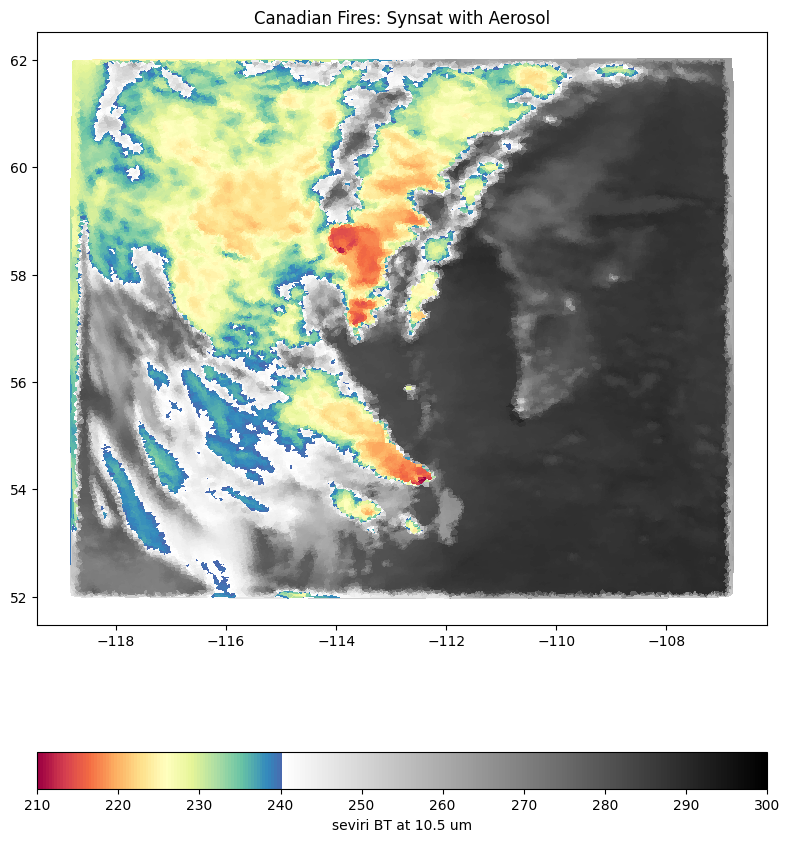

In [10]:
fig, axs = plt.subplots(figsize=(8, 9))
plt.sca(axs)
plt.tripcolor(x, y, v, **pkws)
plt.title("Canadian Fires: Synsat with Aerosol")
plt.colorbar(orientation="horizontal", label=f"{instrument} BT at 10.5 um")

plt.tight_layout()